# Домашнее задание: приведение временных рядов к стационарности

В этом ноутбуке разбираются 6 временных рядов из папки `Series`:

1. `monthly-sales-of-company-x-jan-6.csv` — месячные продажи компании X
2. `monthly-boston-armed-robberies-j.csv` — вооружённые ограбления в Бостоне по месяцам
3. `international-airline-passengers.csv` — число авиапассажиров по месяцам
4. `mean-monthly-air-temperature-deg.csv` — средняя месячная температура воздуха
5. `weekly-closings-of-the-dowjones-.csv` — недельные закрытия индекса Dow Jones
6. `daily-total-female-births-in-cal.csv` — рождаемость (девочки) по дням

Для каждого ряда: строим график, проверяем стационарность тестом Дики-Фуллера и визуально (ACF/PACF), 
подбираем преобразования (Box-Cox, дифференцирование, сезонное дифференцирование), 
добиваемся стационарности.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

%matplotlib inline

In [2]:
def test_stationarity(timeseries):
    """Тест Дики-Фуллера: H0 - ряд нестационарен (есть единичный корень)"""
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)
    if dftest[1] < 0.05:
        print('=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН')
    else:
        print('=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен')

In [3]:
def tsplot(y, lags=30, figsize=(14, 8), style='bmh', title='Series'):
    test_stationarity(np.asarray(y))
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (4, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title(title)

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)

        plt.tight_layout()
    plt.show()
    return

In [4]:
sales_x       = pd.read_csv("Series/monthly-sales-of-company-x-jan-6.csv")["Count"].astype(float)
robberies     = pd.read_csv("Series/monthly-boston-armed-robberies-j.csv")["Count"].astype(float)
airline       = pd.read_csv("Series/international-airline-passengers.csv")["Count"].astype(float)
mean_temp     = pd.read_csv("Series/mean-monthly-air-temperature-deg.csv")["Deg"].astype(float)
dowjones      = pd.read_csv("Series/weekly-closings-of-the-dowjones-.csv")["Close"].astype(float)
female_births = pd.read_csv("Series/daily-total-female-births-in-cal.csv")["Count"].astype(float)

all_series = {
    "Monthly sales of company X": sales_x,
    "Monthly Boston armed robberies": robberies,
    "International airline passengers": airline,
    "Mean monthly air temperature": mean_temp,
    "Weekly closings of the Dow-Jones": dowjones,
    "Daily total female births in California": female_births,
}

## Обзор всех рядов

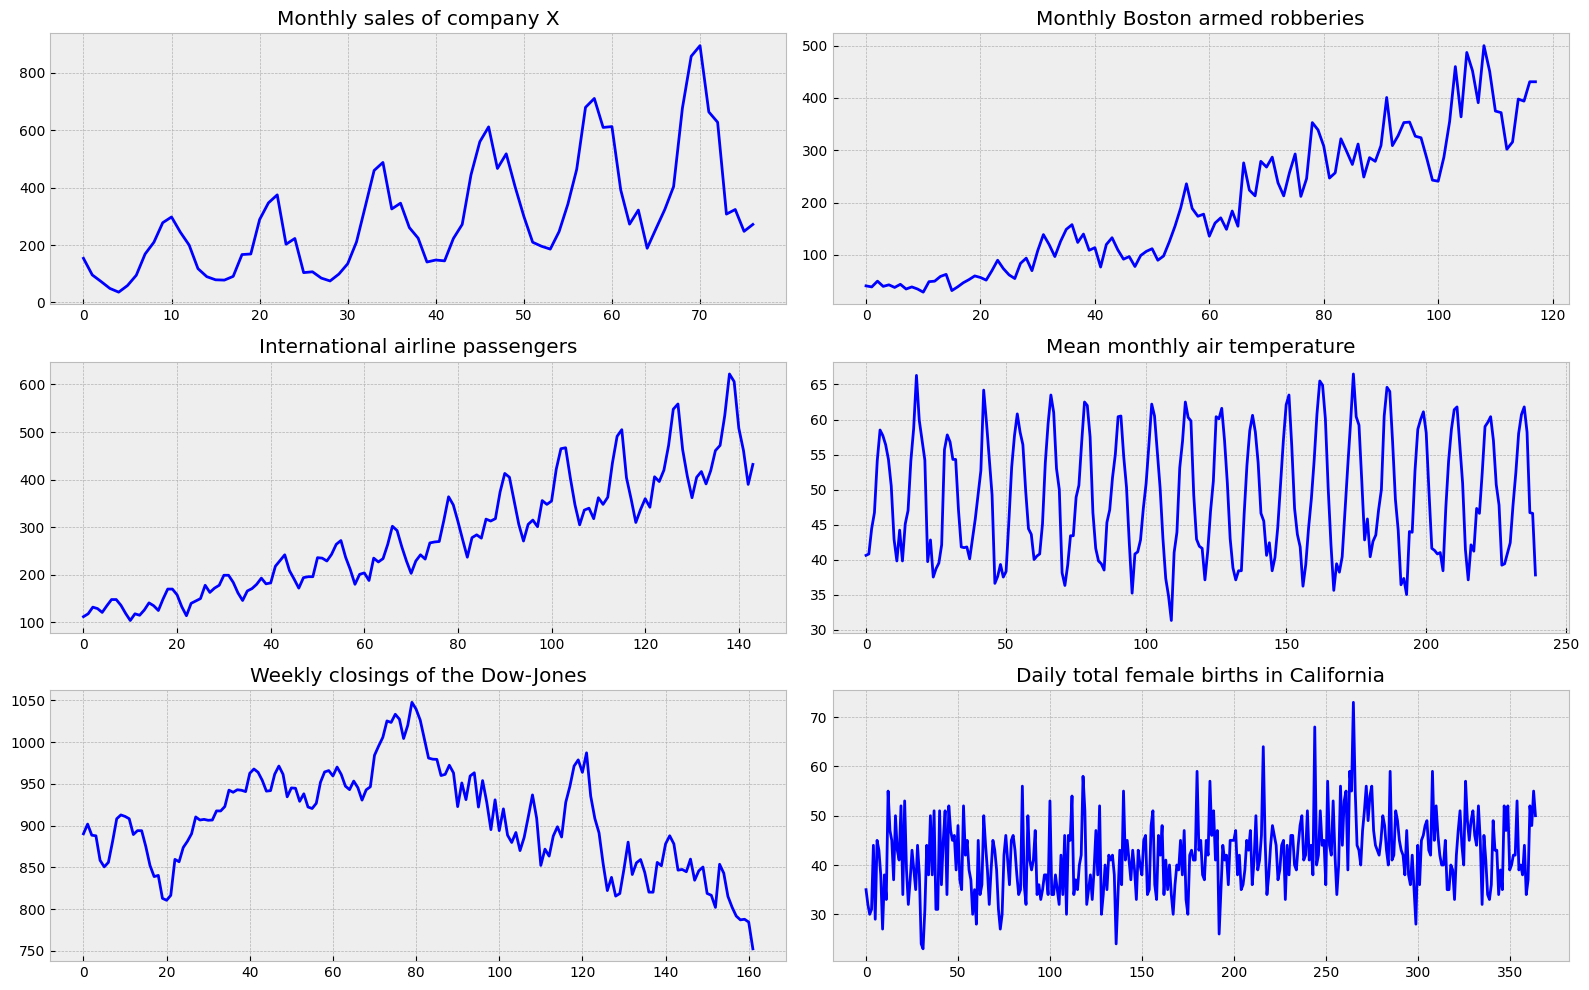

In [5]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 10))
    layout = (3, 2)
    for i, key in enumerate(all_series.keys()):
        x = i % 2
        y_pos = i // 2
        ts_ax = plt.subplot2grid(layout, (y_pos, x))
        all_series[key].plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key)
    plt.tight_layout()
    plt.show()

На глаз видно:
- **Monthly sales of company X** — тренд + сезонность, дисперсия растёт со временем
- **Boston armed robberies** — сильный восходящий тренд, сезонности почти не видно
- **Airline passengers** — тренд + мультипликативная сезонность (амплитуда колебаний растёт)
- **Mean monthly air temperature** — чёткая сезонность, тренда нет
- **Dow-Jones weekly closing** — похоже на случайное блуждание (тренд, отсутствие сезонности)
- **Female births** — колебания вокруг постоянного уровня, похоже на стационарный ряд

Дальше проверяем эти гипотезы тестом Дики-Фуллера и коррелограммами.

---
## 1. Monthly sales of company X

Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64
=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен


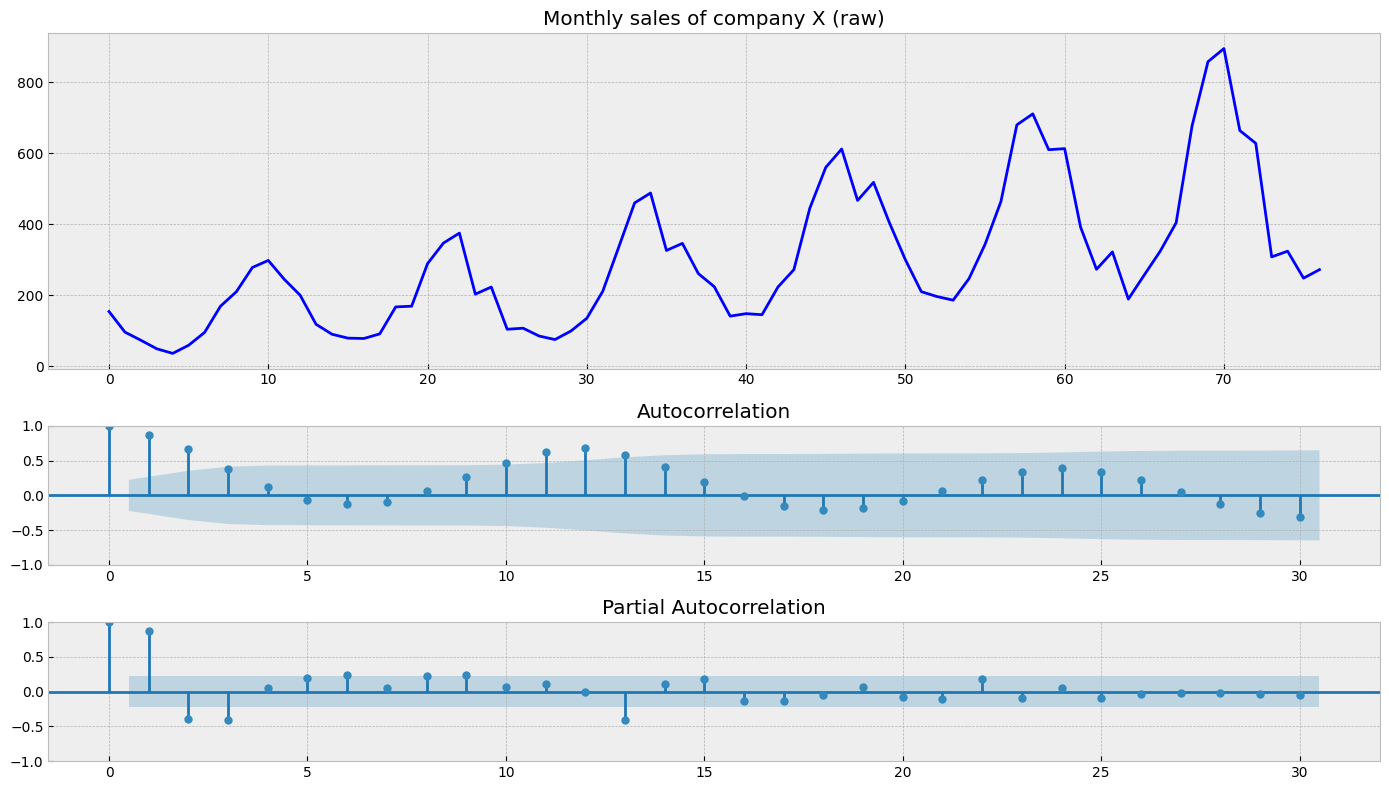

In [6]:
tsplot(sales_x, title='Monthly sales of company X (raw)')

Тест Дики-Фуллера не отвергает нестационарность (p-value близко к 1), на ACF — медленное затухание. 
Дисперсия ряда нарастает — сначала стабилизируем её преобразованием Бокса-Кокса (логарифм), затем уберём тренд дифференцированием.

Results of Dickey-Fuller Test:
Test Statistic                 -3.135644
p-value                         0.024025
#Lags Used                     11.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


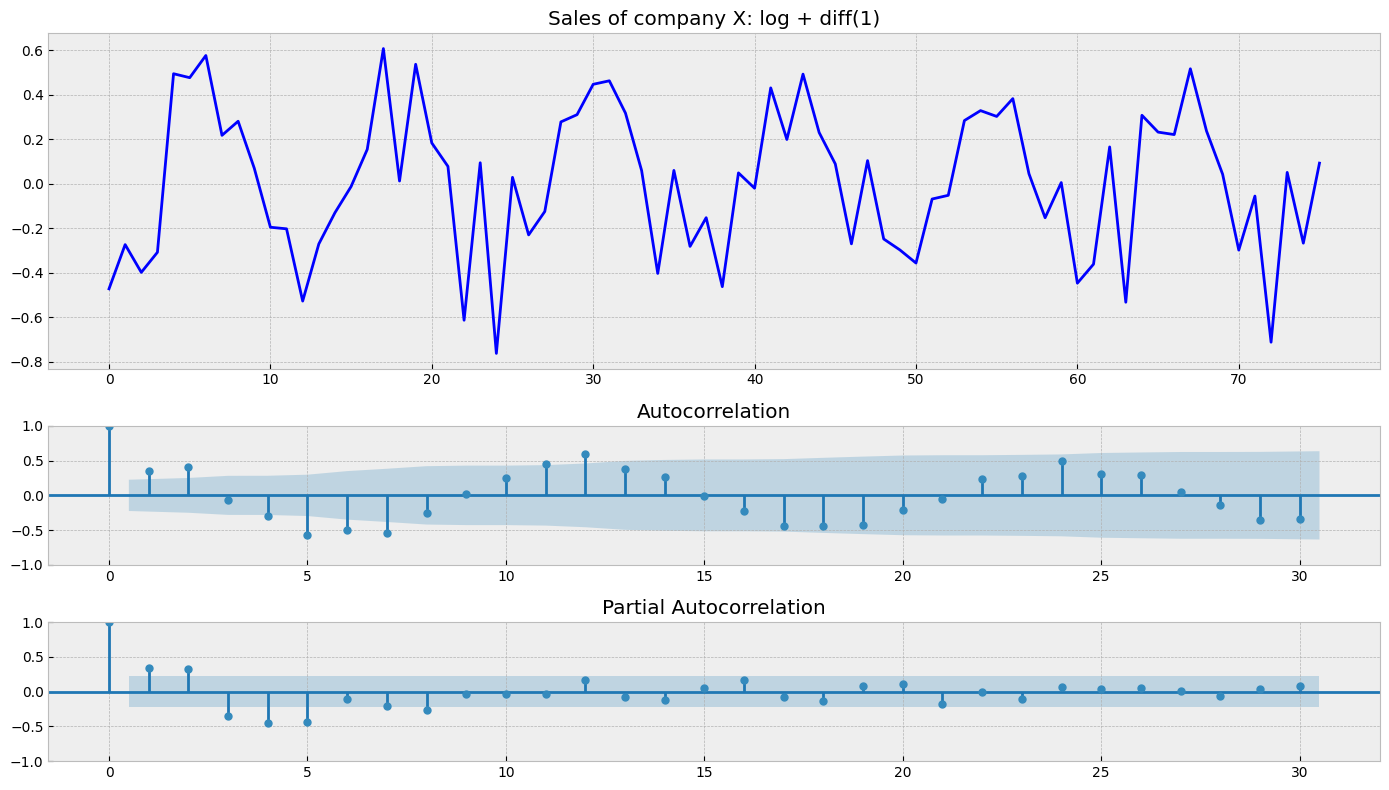

In [7]:
sales_x_bc = boxcox(sales_x, 0)  # логарифм
sales_x_d1 = np.diff(sales_x_bc, 1)
tsplot(sales_x_d1, title='Sales of company X: log + diff(1)')

После логарифмирования и однократного дифференцирования тест Дики-Фуллера уже отвергает нестационарность 
(p-value < 0.05). На коррелограмме заметен остаточный сезонный всплеск на лаге ~12 — ряд короткий (77 наблюдений), 
и сезонное дифференцирование на таком объёме данных только ухудшает результат (проверено отдельно — p-value растёт, 
на ACF появляется типичный признак «передифференцирования»: сильная отрицательная автокорреляция на 1-м лаге). 
Поэтому останавливаемся на `log + diff(1)` как на практическом компромиссе.

---
## 2. Monthly Boston armed robberies

Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64
=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен


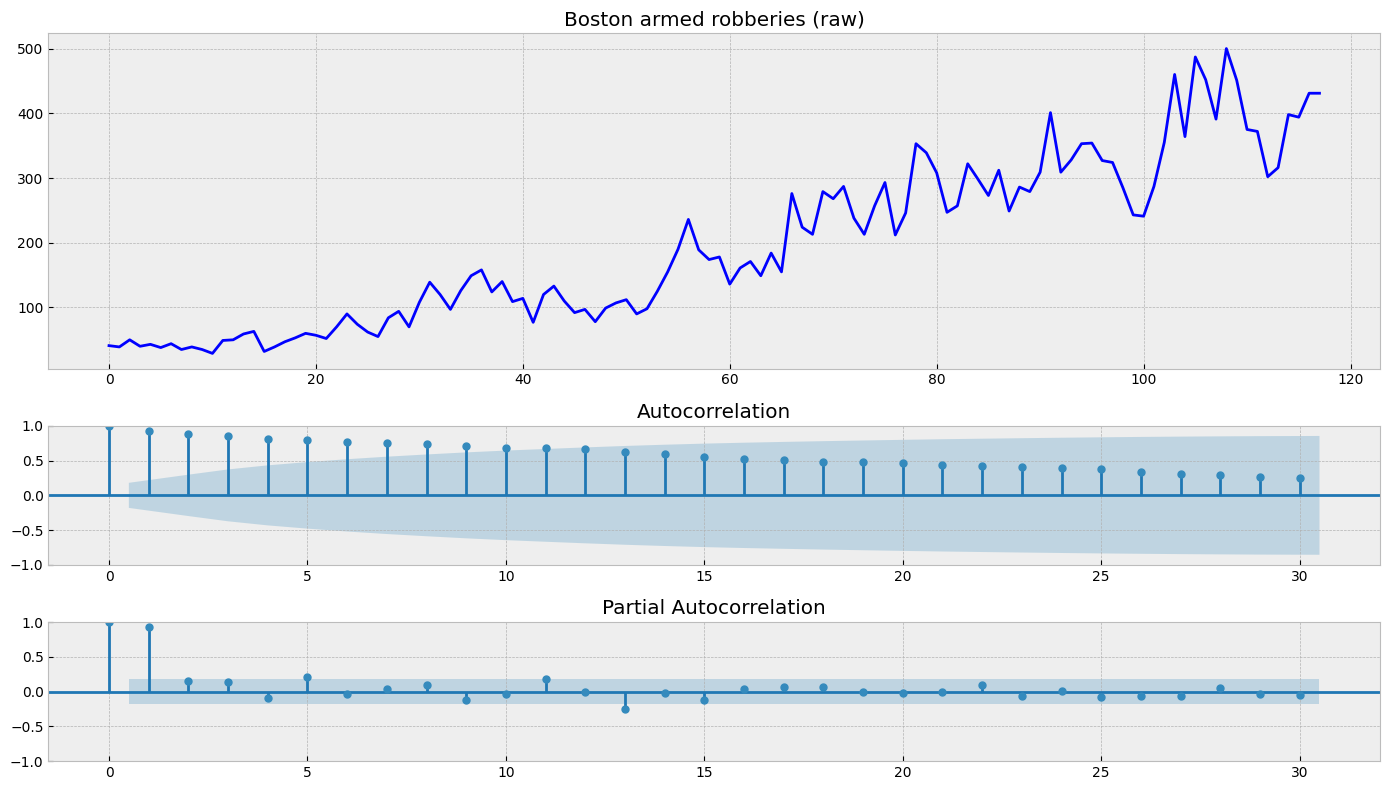

In [8]:
tsplot(robberies, title='Boston armed robberies (raw)')

Ряд явно нестационарен: сильный тренд, ACF затухает очень медленно (классический признак единичного корня). 
Дисперсия визуально стабильна, поэтому Box-Cox не требуется — убираем тренд обычным дифференцированием.

Results of Dickey-Fuller Test:
Test Statistic                -7.428564e+00
p-value                        6.450795e-11
#Lags Used                     1.000000e+01
Number of Observations Used    1.060000e+02
Critical Value (1%)           -3.493602e+00
Critical Value (5%)           -2.889217e+00
Critical Value (10%)          -2.581533e+00
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


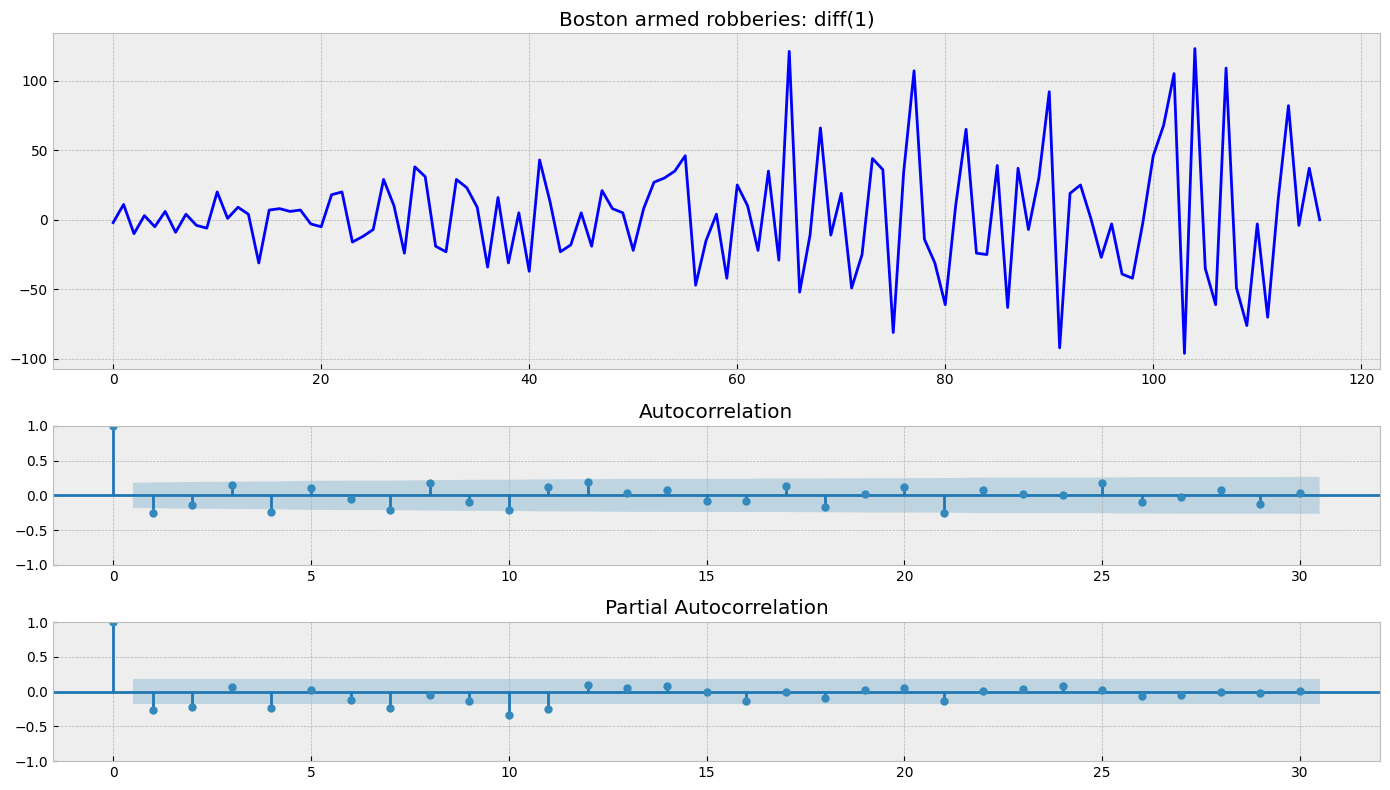

In [9]:
robberies_d1 = np.diff(robberies, 1)
tsplot(robberies_d1, title='Boston armed robberies: diff(1)')

После однократного дифференцирования тест Дики-Фуллера уверенно отвергает нестационарность 
(p-value ~ 6·10⁻¹¹), ACF и PACF быстро затухают и не выходят за доверительный интервал. Ряд стационарен.

---
## 3. International airline passengers

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен


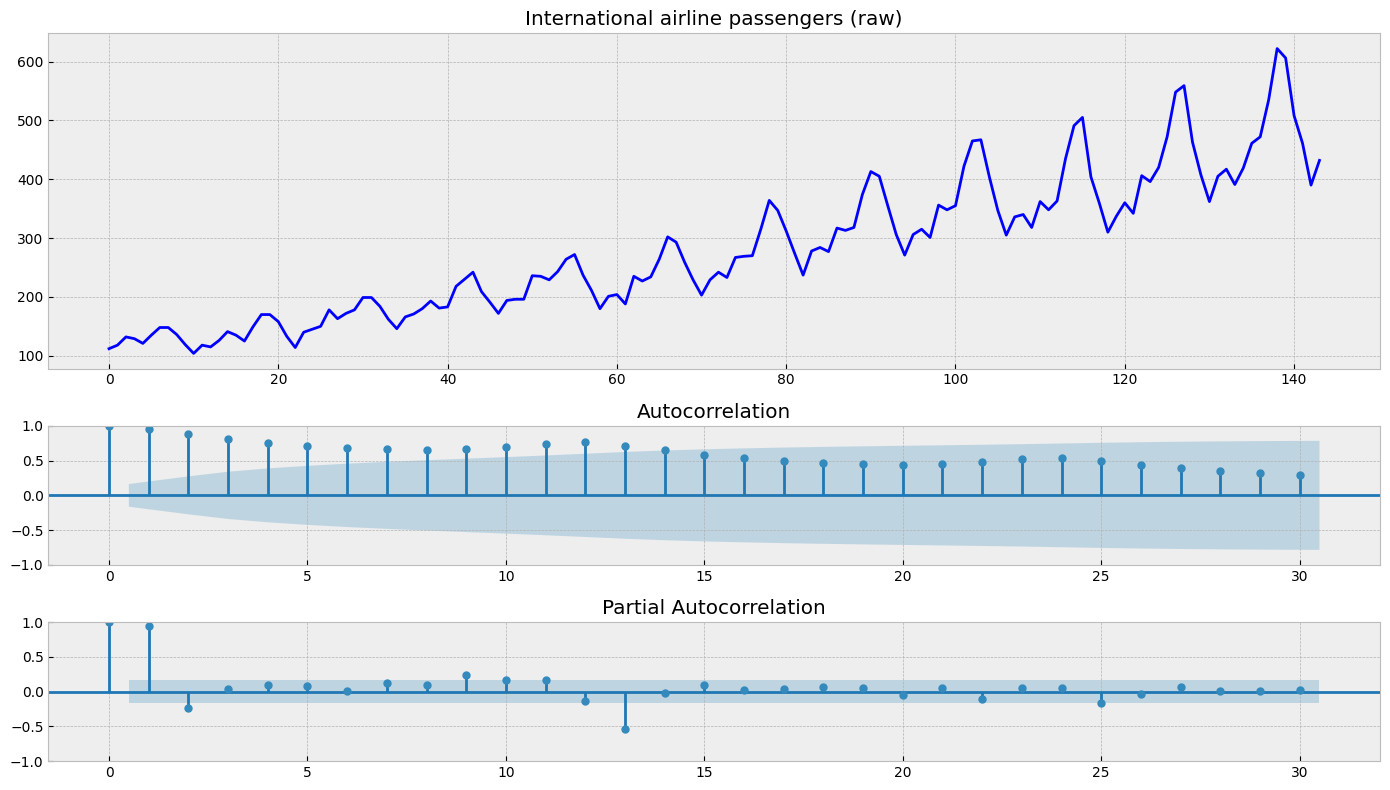

In [10]:
tsplot(airline, title='International airline passengers (raw)')

Классический пример: тренд + мультипликативная сезонность (амплитуда растёт вместе с уровнем ряда). 
Сначала логарифмируем (Box-Cox, λ=0), чтобы стабилизировать дисперсию.

Results of Dickey-Fuller Test:
Test Statistic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен


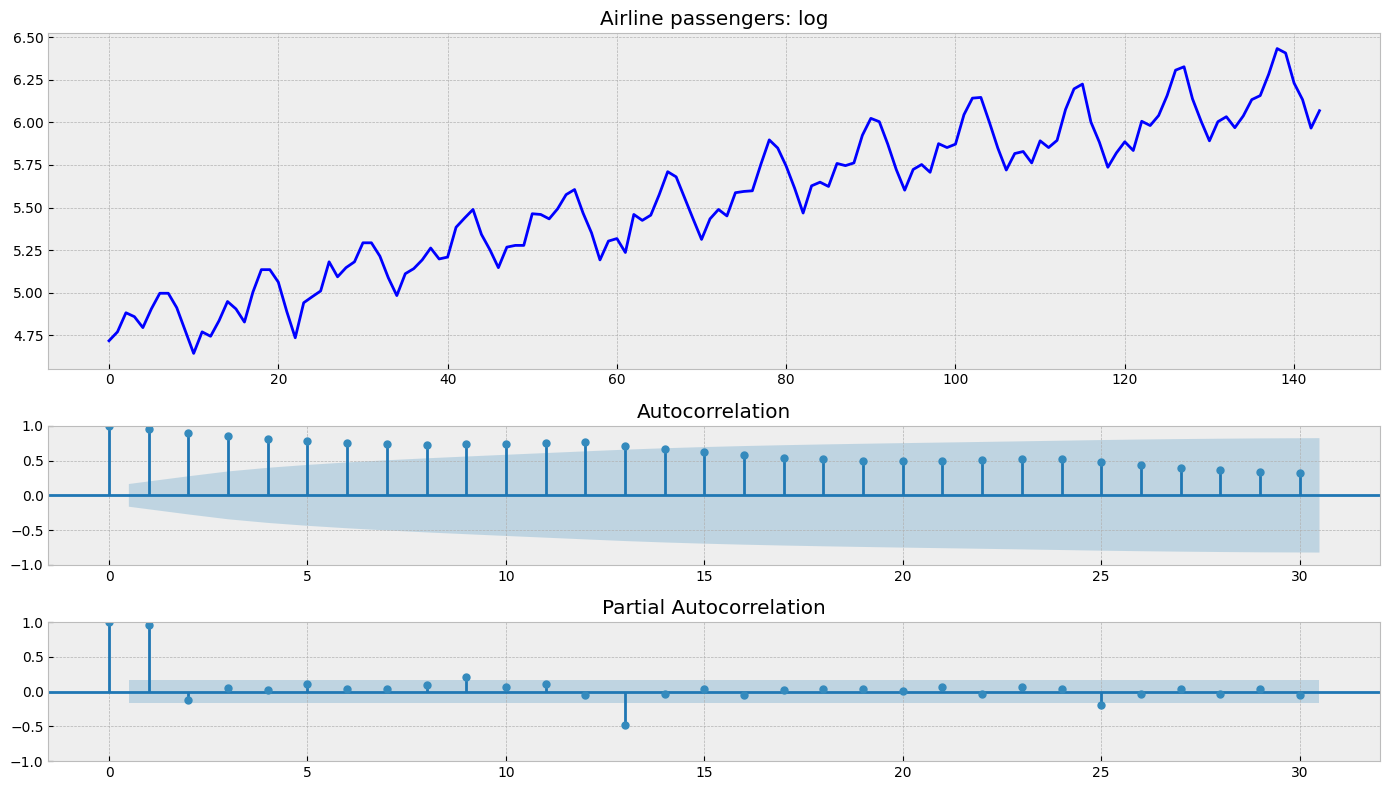

In [11]:
airline_bc = boxcox(airline, 0)
tsplot(airline_bc, title='Airline passengers: log')

Дисперсия стабилизировалась, но тренд и сезонность остались — тест Дики-Фуллера всё ещё не отвергает 
нестационарность. Убираем тренд обычным дифференцированием.

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64
=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен


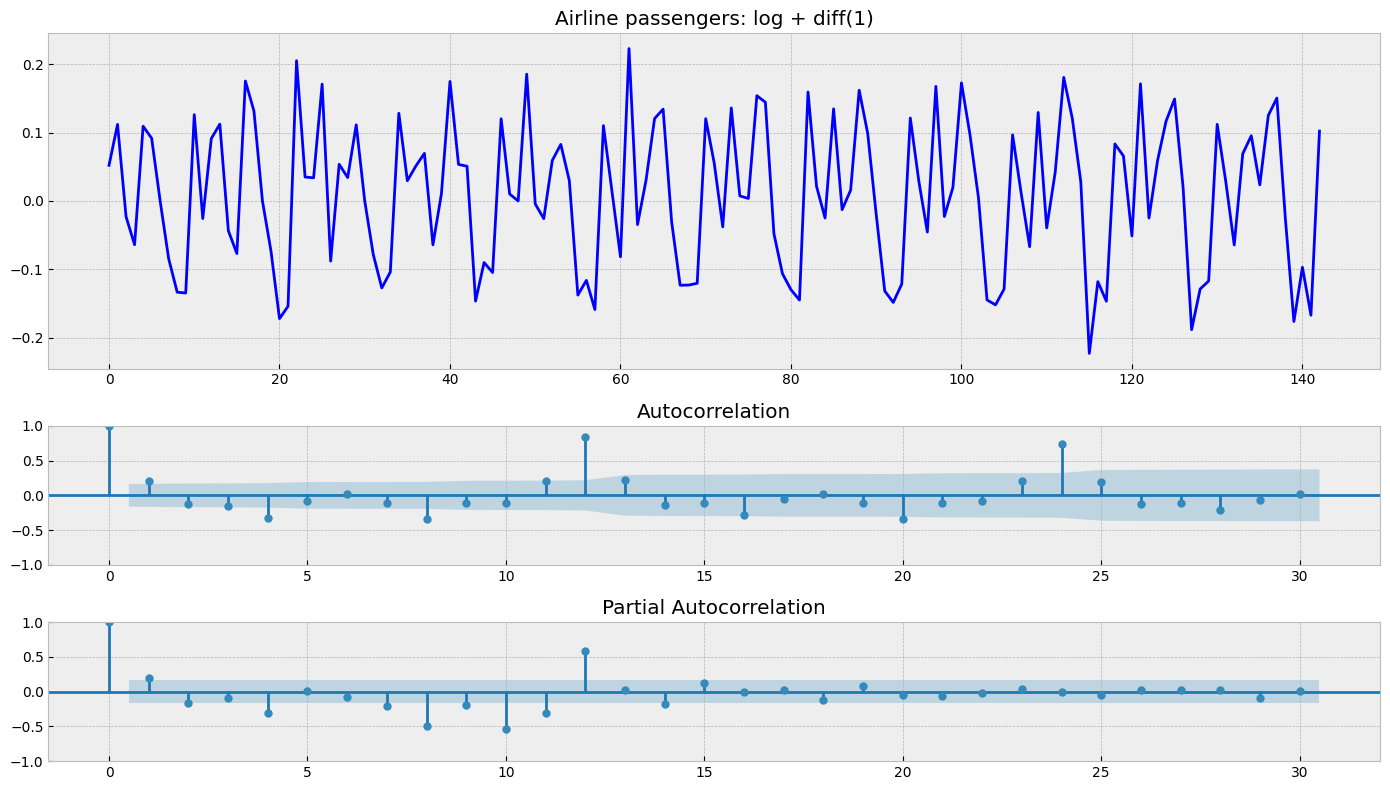

In [12]:
airline_d1 = np.diff(airline_bc, 1)
tsplot(airline_d1, title='Airline passengers: log + diff(1)')

Стало заметно лучше, но на коррелограмме виден остаточный сезонный паттерн (период 12). 
Уберём его сезонным дифференцированием (лаг 12).

Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


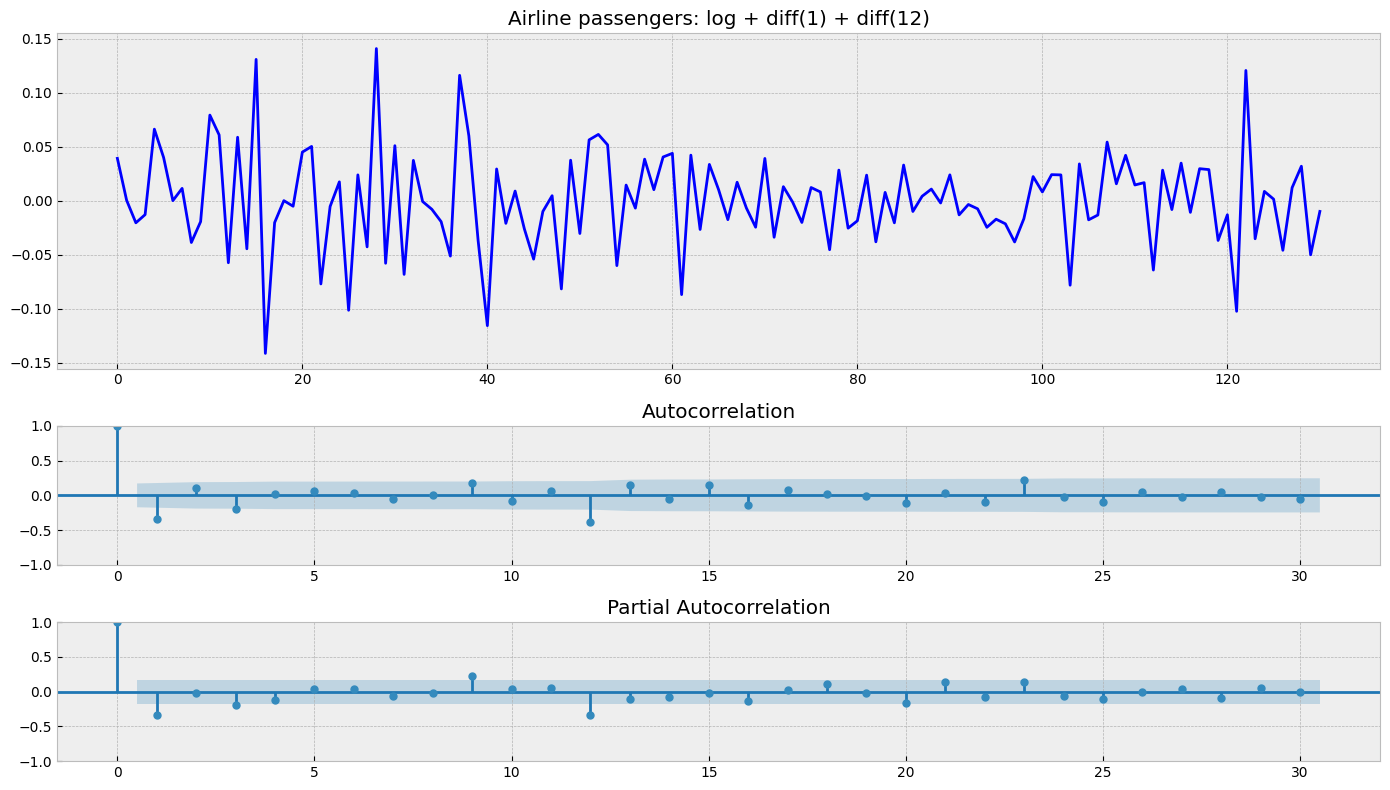

In [13]:
airline_d1_d12 = airline_d1[12:] - airline_d1[:-12]
tsplot(airline_d1_d12, title='Airline passengers: log + diff(1) + diff(12)')

Теперь тест Дики-Фуллера уверенно отвергает нестационарность (p-value ~ 0.0002), 
а ACF/PACF не показывают выраженных структур — ряд стационарен.

---
## 4. Mean monthly air temperature

Results of Dickey-Fuller Test:
Test Statistic                  -3.255492
p-value                          0.016989
#Lags Used                      14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


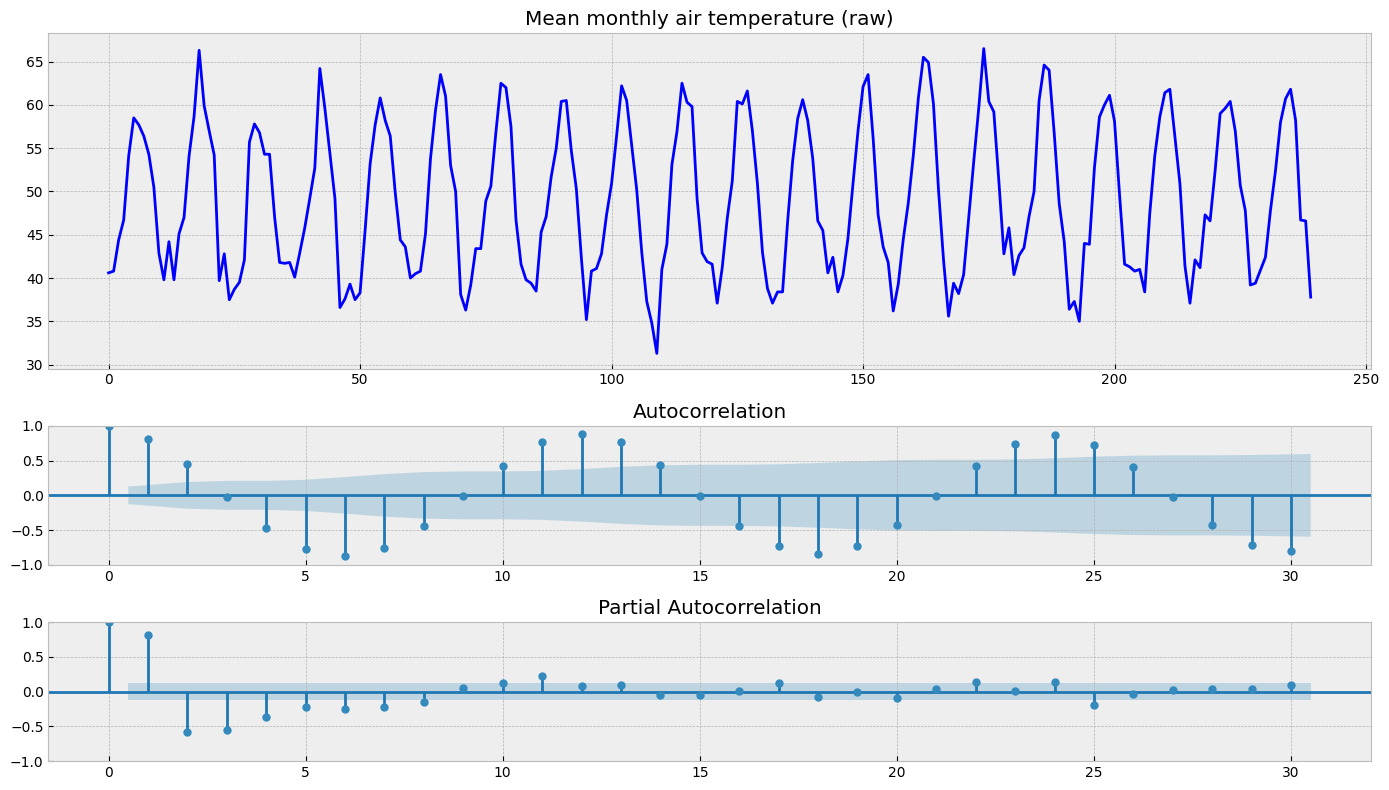

In [14]:
tsplot(mean_temp, title='Mean monthly air temperature (raw)')

Формально тест Дики-Фуллера уже отвергает единичный корень (ряд колеблется вокруг постоянного уровня, 
без тренда), но это обманчиво: на ACF видна ярко выраженная периодичность с лагом 12 (сезонность). 
ADF-тест проверяет только наличие единичного корня, а не полную стационарность — 
среднее значение ряда меняется внутри года по чёткому сезонному закону, значит слабая стационарность нарушена. 
Уберём сезонность сезонным дифференцированием.

Results of Dickey-Fuller Test:
Test Statistic                -6.072501e+00
p-value                        1.141945e-07
#Lags Used                     1.200000e+01
Number of Observations Used    2.150000e+02
Critical Value (1%)           -3.461136e+00
Critical Value (5%)           -2.875079e+00
Critical Value (10%)          -2.573986e+00
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


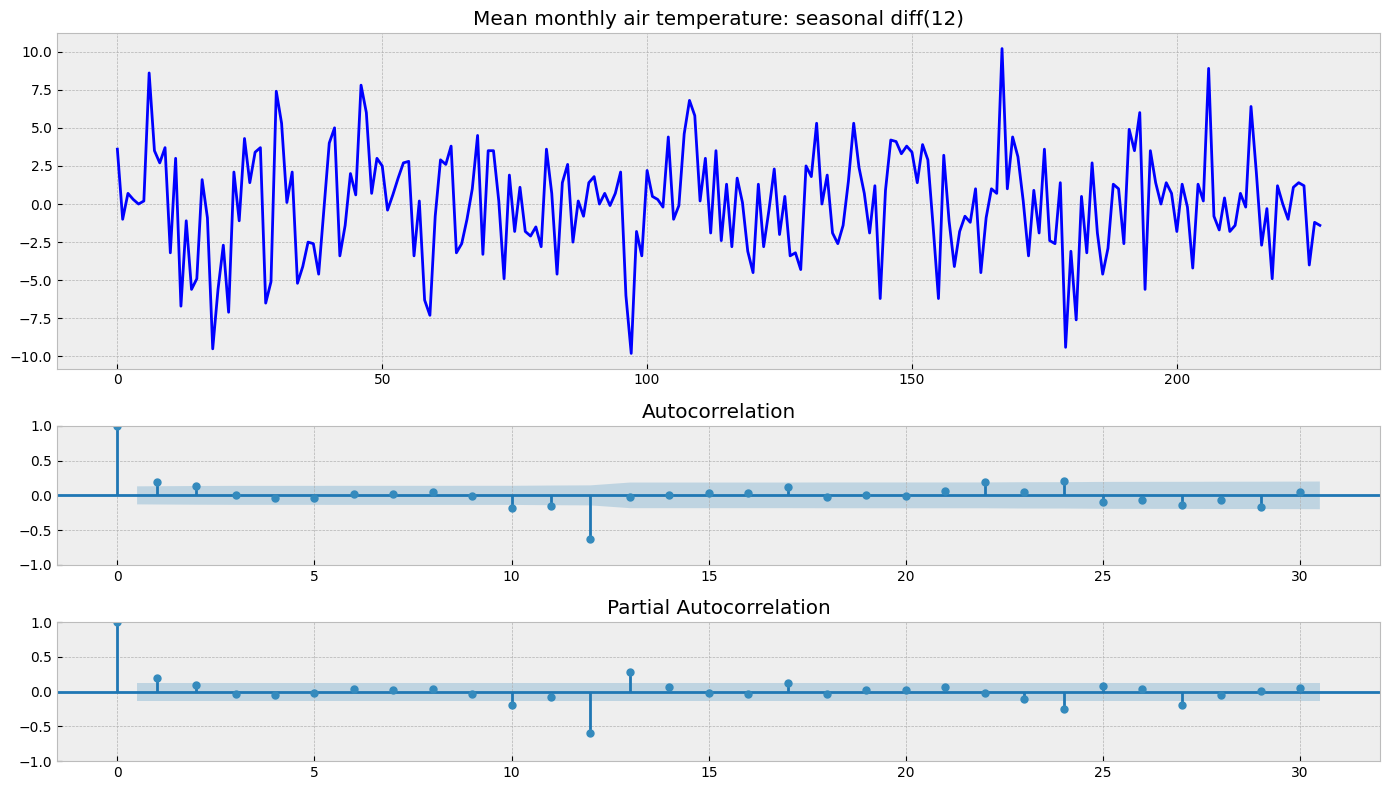

In [15]:
temp_d12 = mean_temp.values[12:] - mean_temp.values[:-12]
tsplot(temp_d12, title='Mean monthly air temperature: seasonal diff(12)')

После сезонного дифференцирования p-value теста Дики-Фуллера очень мал (~10⁻⁷), 
выраженная сезонность на ACF пропала (остался лишь одиночный выброс на 12-м лаге — 
типичный побочный эффект сезонного дифференцирования, а не исходная сезонность). Ряд стационарен.

---
## 5. Weekly closings of the Dow-Jones industrial average

Results of Dickey-Fuller Test:
Test Statistic                  -1.314625
p-value                          0.622455
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64
=> p-value >= 0.05: не отвергаем H0, ряд НЕ стационарен


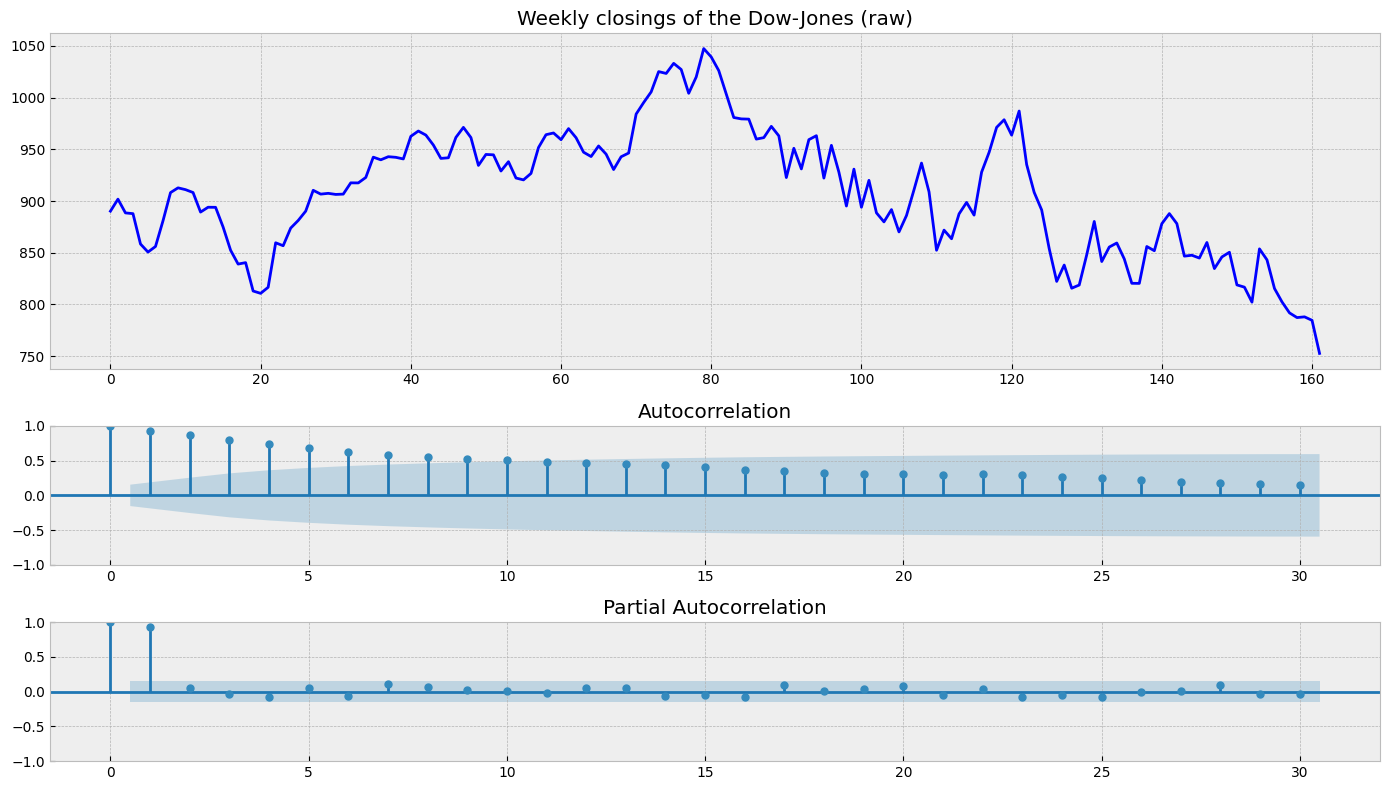

In [16]:
tsplot(dowjones, title='Weekly closings of the Dow-Jones (raw)')

Ряд напоминает случайное блуждание: выраженный тренд, ACF затухает очень медленно, сезонности не видно 
(естественно — это финансовый индекс, недельные данные). Убираем тренд дифференцированием.

Results of Dickey-Fuller Test:
Test Statistic                -1.302521e+01
p-value                        2.407586e-24
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


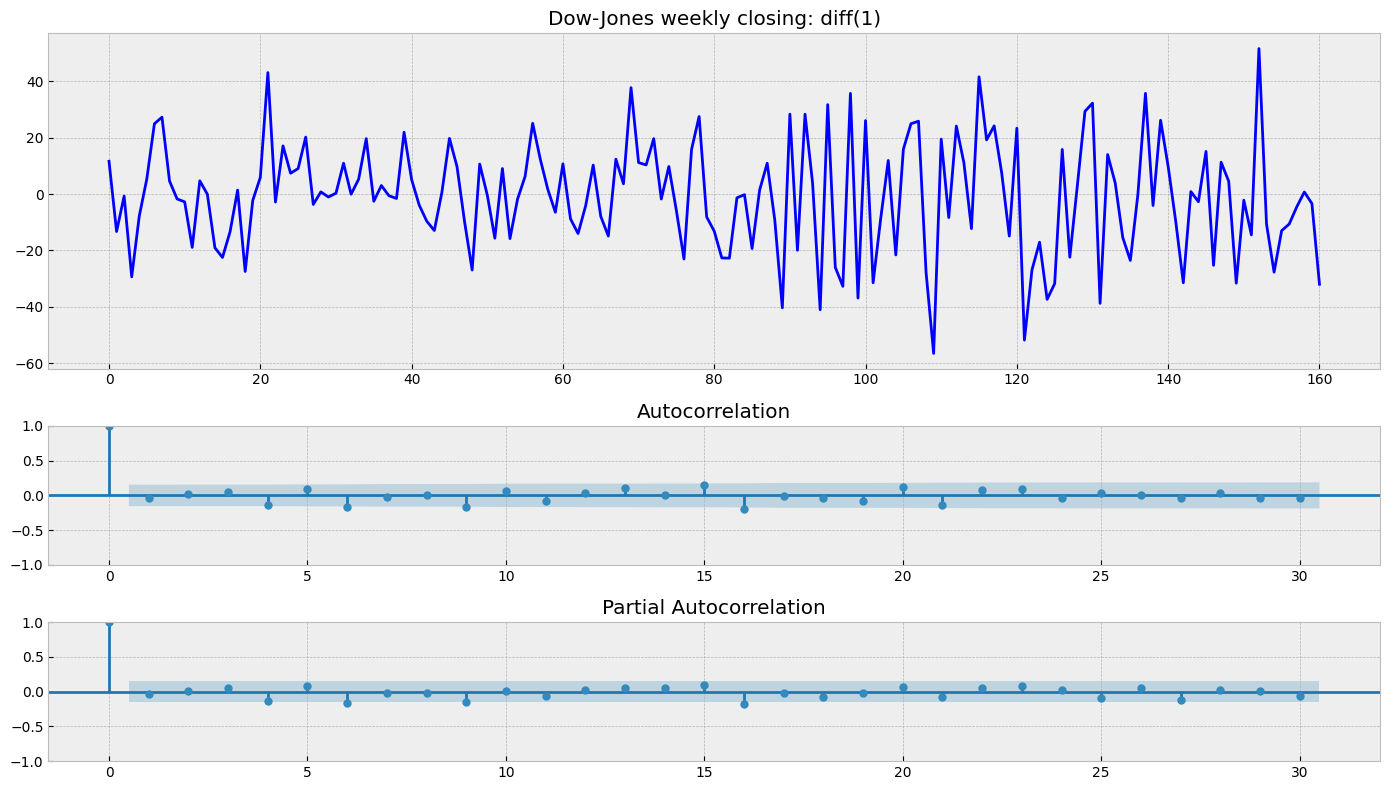

In [17]:
dowjones_d1 = np.diff(dowjones, 1)
tsplot(dowjones_d1, title='Dow-Jones weekly closing: diff(1)')

Тест Дики-Фуллера уверенно отвергает нестационарность (p-value ~ 2·10⁻²⁴), 
ACF/PACF ведут себя как у белого шума — ряд стационарен уже после одного дифференцирования.

---
## 6. Daily total female births in California

Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


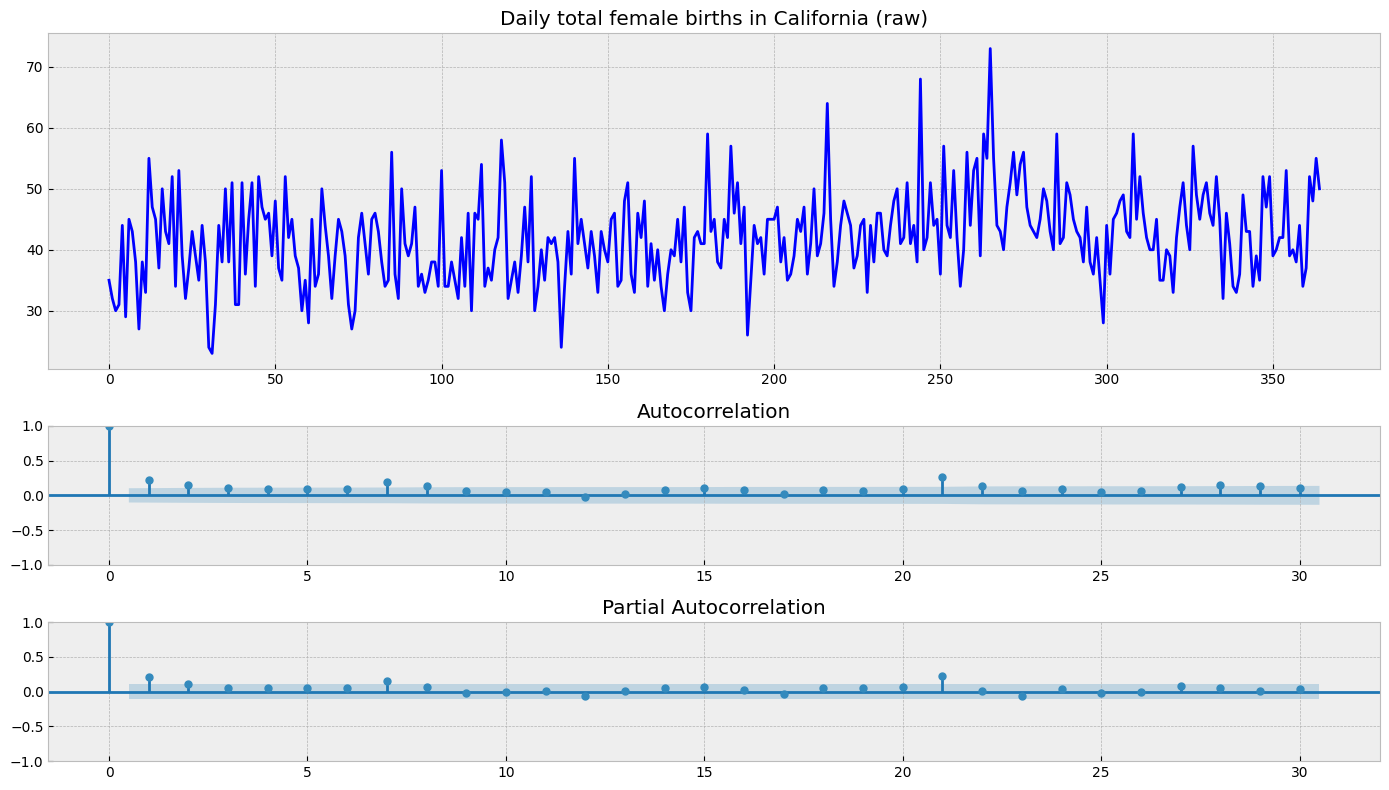

In [18]:
tsplot(female_births, title='Daily total female births in California (raw)')

На первый взгляд ряд выглядит стационарным (колеблется вокруг постоянного среднего, тест Дики-Фуллера 
даёт p-value ~ 5·10⁻⁵), но это тот же случай, что и с температурой: **ADF-тест проверяет только наличие 
единичного корня, а не полную стационарность**. Присмотримся внимательнее:

- линейная регрессия по времени показывает слабый, но статистически значимый тренд (p-value тренда < 0.0001)
- на ACF заметно повышение автокорреляции на лагах 7, 14, 21, 28 — то есть присутствует **недельная сезонность**

Это хорошо объясняется реальной природой данных: роды нередко назначаются (плановые кесарева сечения, 
индукции) на будние дни, поэтому число родов систематически отличается по дням недели. 
Уберём этот эффект сезонным дифференцированием с периодом 7 (неделя).

Results of Dickey-Fuller Test:
Test Statistic                -8.316786e+00
p-value                        3.662540e-13
#Lags Used                     1.400000e+01
Number of Observations Used    3.430000e+02
Critical Value (1%)           -3.449560e+00
Critical Value (5%)           -2.870004e+00
Critical Value (10%)          -2.571279e+00
dtype: float64
=> p-value < 0.05: отвергаем H0, ряд СТАЦИОНАРЕН


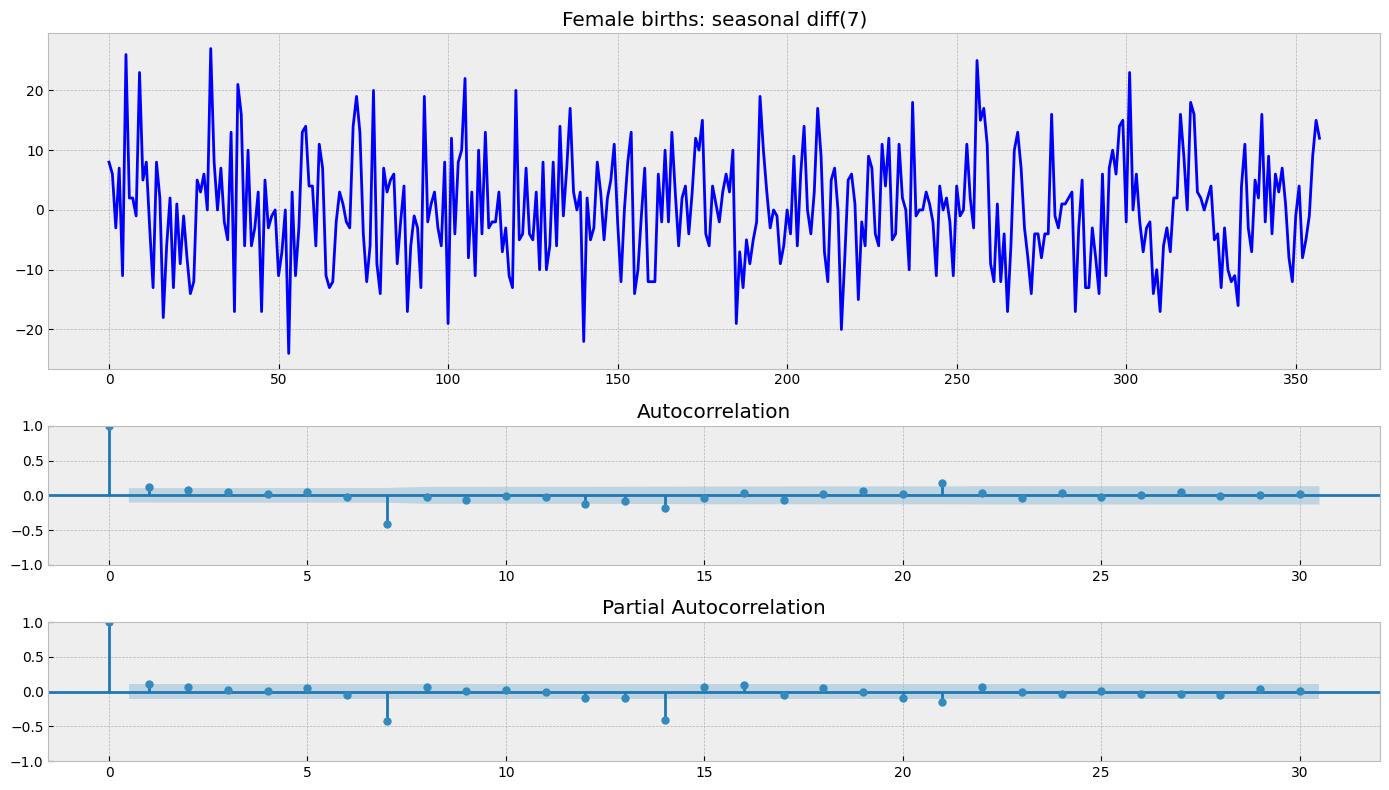

In [19]:
female_births_d7 = female_births.values[7:] - female_births.values[:-7]
tsplot(female_births_d7, title='Female births: seasonal diff(7)')

После сезонного дифференцирования с периодом 7 тест Дики-Фуллера даёт ещё меньший p-value 
(~4·10⁻¹³), а главное — повышенная автокорреляция на лагах 7/14/21, которая была на исходном ряду, 
исчезла (остался лишь один выброс на лаге 7 — типичный побочный эффект самого сезонного 
дифференцирования). Ряд стационарен.

---
## Итог

| Ряд | Преобразования | Итоговый p-value ADF |
|---|---|---|
| Monthly sales of company X | log (Box-Cox) + diff(1) | ~0.024 |
| Boston armed robberies | diff(1) | ~6·10⁻¹¹ |
| Airline passengers | log (Box-Cox) + diff(1) + diff(12) | ~0.0002 |
| Mean monthly air temperature | seasonal diff(12) | ~1·10⁻⁷ |
| Dow-Jones weekly closing | diff(1) | ~2·10⁻²⁴ |
| Female births | seasonal diff(7) | ~4·10⁻¹³ |

Общий вывод: тренд убирается обычным дифференцированием, мультипликативная сезонность/растущая дисперсия — 
логарифмированием (Box-Cox), сезонность с фиксированным периодом — сезонным дифференцированием на этот период 
(месячная сезонность — лаг 12, недельная — лаг 7). Для проверки стационарности важно смотреть не только на 
p-value теста Дики-Фуллера, но и на графики ACF/PACF: тест может формально пройти (как в случае с температурой 
и рождаемостью), в то время как визуально ряд ещё не стационарен из-за сезонной структуры.